# EDA & cleaning

We ask whether GPU pricing and value move with crypto, equity markets, and the GPU supply chain. This notebook (1) acquires raw data: GPU export, BTC, S&P 500, and supply-chain firms (TSMC fab, NVIDIA/AMD designers, Micron memory), then (2) cleans GPU data and builds yearly medians. Outputs: `gpu_clean.csv`, `gpu_yearly.csv`. Raw files written to `data/raw/`.

## Setup & paths

In [41]:
from pathlib import Path
import re
import json
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_RAW = ROOT / "data" / "raw"
DATA_PROC = ROOT / "data" / "processed"
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROC.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## Data acquisition

Fetch or export all raw inputs: GPU CSV from JSON, then BTC, S&P 500, and GPU supply-chain yearly returns (TSMC, NVIDIA, AMD, Micron) via yfinance.

In [42]:
# Export gpu_price.json → gpu_data.csv
with open(DATA_RAW / "gpu_price.json", "r") as f:
    data = json.load(f)
gpu_export = pd.DataFrame([v for v in data.values()])
gpu_export.to_csv(DATA_RAW / "gpu_data.csv", index=False)
print(f"Exported {len(gpu_export)} rows to data/raw/gpu_data.csv")

Exported 1685 rows to data/raw/gpu_data.csv


In [43]:
# Bitcoin yearly average price
btc_hist = yf.Ticker("BTC-USD").history(period="max")
btc_hist.index = btc_hist.index.tz_localize(None)
btc_yearly = btc_hist.resample("YE").agg({"Close": "mean"}).dropna()
btc_yearly = btc_yearly.rename(columns={"Close": "btc_avg_price"})
btc_yearly["year"] = btc_yearly.index.year
btc_yearly[["year", "btc_avg_price"]].to_csv(DATA_RAW / "btc_yearly.csv", index=False)
print(f"Saved {len(btc_yearly)} years to data/raw/btc_yearly.csv")

Saved 13 years to data/raw/btc_yearly.csv


In [44]:
# S&P 500 yearly close and return
sp_hist = yf.Ticker("^GSPC").history(period="max")
sp_hist.index = sp_hist.index.tz_localize(None)
sp_yearly = sp_hist.resample("YE").agg({"Close": "last"}).dropna()
sp_yearly = sp_yearly.rename(columns={"Close": "sp500_close"})
sp_yearly["year"] = sp_yearly.index.year
sp_yearly["sp500_return"] = sp_yearly["sp500_close"].pct_change()
sp_yearly[["year", "sp500_close", "sp500_return"]].to_csv(DATA_RAW / "sp500_yearly.csv", index=False)
print(f"Saved {len(sp_yearly)} years to data/raw/sp500_yearly.csv")

Saved 100 years to data/raw/sp500_yearly.csv


In [45]:
# GPU supply chain: TSMC (fab), NVIDIA, AMD (designers), Micron (memory) — yearly close and return
supply_chain = [("TSM", "tsmc"), ("NVDA", "nvda"), ("AMD", "amd"), ("MU", "micron")]
out_sc = None
for ticker, prefix in supply_chain:
    h = yf.Ticker(ticker).history(period="max")
    if h.empty:
        continue
    h.index = h.index.tz_localize(None)
    yr = h.resample("YE").agg({"Close": "last"}).dropna()
    yr = yr.rename(columns={"Close": f"{prefix}_close"})
    yr["year"] = yr.index.year
    yr[f"{prefix}_return"] = yr[f"{prefix}_close"].pct_change()
    if out_sc is None:
        out_sc = yr[["year", f"{prefix}_close", f"{prefix}_return"]].copy()
    else:
        out_sc = out_sc.merge(yr[["year", f"{prefix}_close", f"{prefix}_return"]], on="year", how="outer")
if out_sc is not None:
    out_sc.sort_values("year").to_csv(DATA_RAW / "supply_chain_yearly.csv", index=False)
    print(f"Saved {len(out_sc)} years to data/raw/supply_chain_yearly.csv")
else:
    print("No supply chain data fetched")

Saved 47 years to data/raw/supply_chain_yearly.csv


## Load GPU and drop subheaders

In [46]:
df = pd.read_csv(DATA_RAW / "gpu_data.csv")
is_subheader = df["Model name"].astype(str).str.strip().str.lower() == "model"
df = df[~is_subheader].copy()
print(f"Rows after dropping subheaders: {len(df)}")
df.head(5)

Rows after dropping subheaders: 1677


,Model name,Launch,Code name,Fab (nm),Transistors (million),Die size (mm),Bus interface,Core clock (MHz),Memory clock (MHz),Core config,...,Branding and Model,Branding and Model Branding and Model.1,MSRP (USD),L2 cache,Clock rate (MHz),Processing power (TFLOPS) Half precision (base),Processing power (TFLOPS) Single precision (base),Processing power (TFLOPS) Double precision (base),Processing power (TFLOPS) XMX Half Precision,Processing power (TFLOPS) Bfloat16
0,NV1,1995-05-22 00:00:00,NV1,SGS 500 nm,1.0,90.0,PCI,75,60,1:1:1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Riva 128,1997-08-25 00:00:00,NV3,SGS 350 nm,4.0,90.0,"AGP 1x, PCI",100,100,1:1:1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Riva 128ZX,1998-02-23 00:00:00,NV3,SGS/TSMC 350 nm,4.0,90.0,"AGP 2x, PCI",100,100,1:1:1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Riva TNT,1998-06-15 00:00:00,NV4,TSMC 350 nm,7.0,90.0,"AGP 2x, PCI",90,110,2:2:2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Vanta,1999-03-22 00:00:00,NV6,TSMC 250 nm,NaN,NaN,"AGP 4x, PCI",100,125,2:2:2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Price (USD) and launch year

In [47]:
def parse_price(val):
    if pd.isna(val) or str(val).strip() in ("", "?", "OEM", "-N/a", "nan"):
        return np.nan
    m = re.search(r"(\d+(?:\.\d+)?)", str(val))
    return float(m.group(1)) if m else np.nan

price_cols = ["Release Price (USD)", "Release price (USD) MSRP", "Release price (USD)", "MSRP (USD)"]
price_series = [df[c].apply(parse_price) for c in price_cols if c in df.columns]
if not price_series:
    df["price_usd_clean"] = np.nan
elif len(price_series) == 1:
    df["price_usd_clean"] = price_series[0]
else:
    df["price_usd_clean"] = pd.concat(price_series, axis=1).bfill(axis=1).iloc[:, 0]

df["Launch"] = pd.to_datetime(df["Launch"], errors="coerce")
df["launch_year"] = df["Launch"].dt.year
print(f"Valid prices: {df['price_usd_clean'].notna().sum()}")

Valid prices: 239


## Performance (TFLOPS) and perf_per_dollar

In [48]:
perf_cols = [
    "Processing power (TFLOPS) Single precision",
    "Processing power (GFLOPS) Single precision",
    "Performance (GFLOPS)",
    "Processing power (GFLOPS)",
]
perf_df = df[[c for c in perf_cols if c in df.columns]].apply(pd.to_numeric, errors="coerce")
for c in perf_df.columns:
    if "GFLOPS" in c and "TFLOPS" not in c:
        perf_df[c] = perf_df[c] / 1000
df["perf_value"] = perf_df.bfill(axis=1).iloc[:, 0]

valid = df["price_usd_clean"].gt(0) & df["perf_value"].notna() & df["launch_year"].notna()
core = df[valid].copy()
core["perf_per_dollar"] = core["perf_value"] / core["price_usd_clean"]
core = core.replace([np.inf, -np.inf], np.nan).dropna(subset=["perf_per_dollar", "launch_year"])
print(f"Rows with price & perf: {len(core)}")
core["perf_per_dollar"].describe()

Rows with price & perf: 118


count    118.000000
mean       0.009926
std        0.012388
min        0.000693
25%        0.003440
50%        0.006138
75%        0.009495
max        0.064147
Name: perf_per_dollar, dtype: float64

## Releases per year

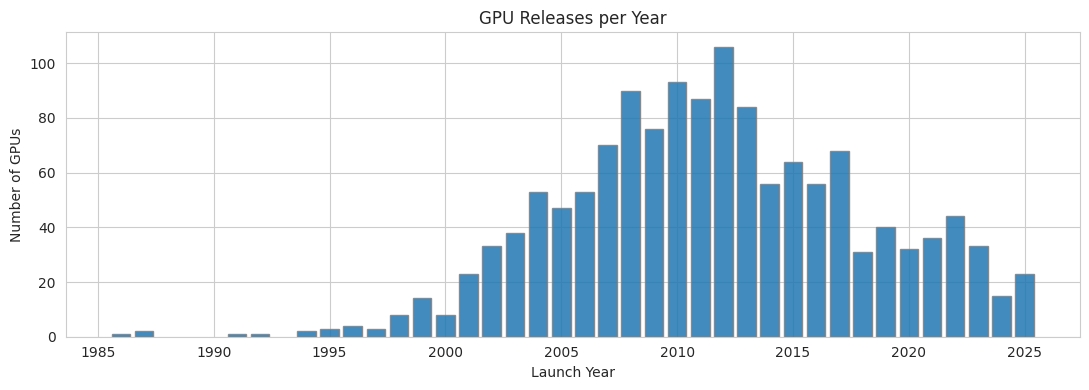

In [49]:
year_counts = df["launch_year"].dropna().astype(int).value_counts().sort_index()
plt.figure(figsize=(11, 4))
plt.bar(year_counts.index, year_counts.values, edgecolor="gray", alpha=0.85)
plt.xlabel("Launch Year")
plt.ylabel("Number of GPUs")
plt.title("GPU Releases per Year")
plt.tight_layout()
plt.show()

## Perf-per-dollar distribution (log scale)

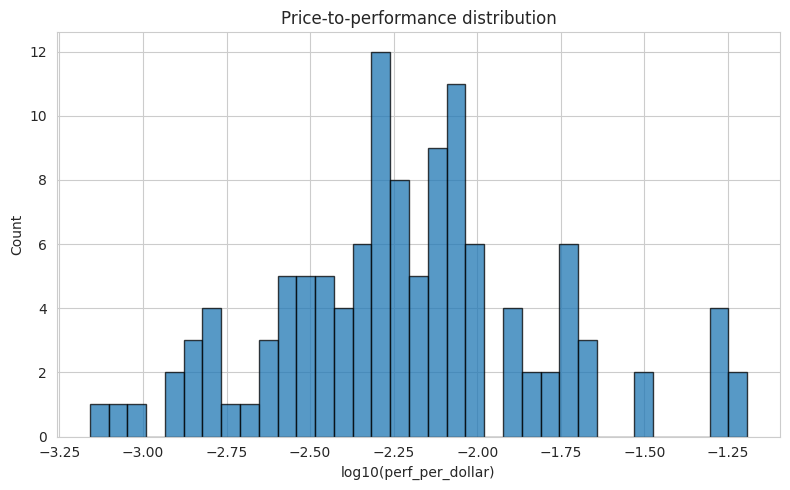

In [50]:
log_ppd = np.log10(core["perf_per_dollar"].replace(0, np.nan).dropna())
log_ppd = log_ppd[np.isfinite(log_ppd)]
plt.figure(figsize=(8, 5))
plt.hist(log_ppd, bins=35, edgecolor="black", alpha=0.75)
plt.xlabel("log10(perf_per_dollar)")
plt.ylabel("Count")
plt.title("Price-to-performance distribution")
plt.tight_layout()
plt.show()

## Best GPU per year (by perf_per_dollar)

In [51]:
best_per_year = (
    core.loc[core.groupby("launch_year")["perf_per_dollar"].idxmax()]
    [["launch_year", "Model name", "Vendor", "price_usd_clean", "perf_value", "perf_per_dollar"]]
    .sort_values("launch_year")
    .rename(columns={"price_usd_clean": "price_usd", "perf_value": "TFLOPS"})
)
best_per_year

,launch_year,Model name,Vendor,price_usd,TFLOPS,perf_per_dollar
1041,2007.0,NaN,AMD,179.0,0.42750,0.002388
1077,2008.0,NaN,AMD,79.0,0.48000,0.006076
1080,2009.0,NaN,AMD,109.0,0.96000,0.008807
1101,2010.0,NaN,AMD,239.0,1.79200,0.007498
209,2011.0,GeForce GTX 560,NVIDIA,199.0,1.08860,0.005470
237,2012.0,GeForce GTX 650 Ti,NVIDIA,150.0,1.42541,0.009503
260,2013.0,GeForce GTX 760,NVIDIA,249.0,2.25790,0.009068
251,2014.0,GeForce GT 730,NVIDIA,69.0,0.69270,0.010039
706,2015.0,NaN,NVIDIA,791.0,2.66240,0.003366
249,2016.0,GeForce GT 710,NVIDIA,35.0,0.36600,0.010457


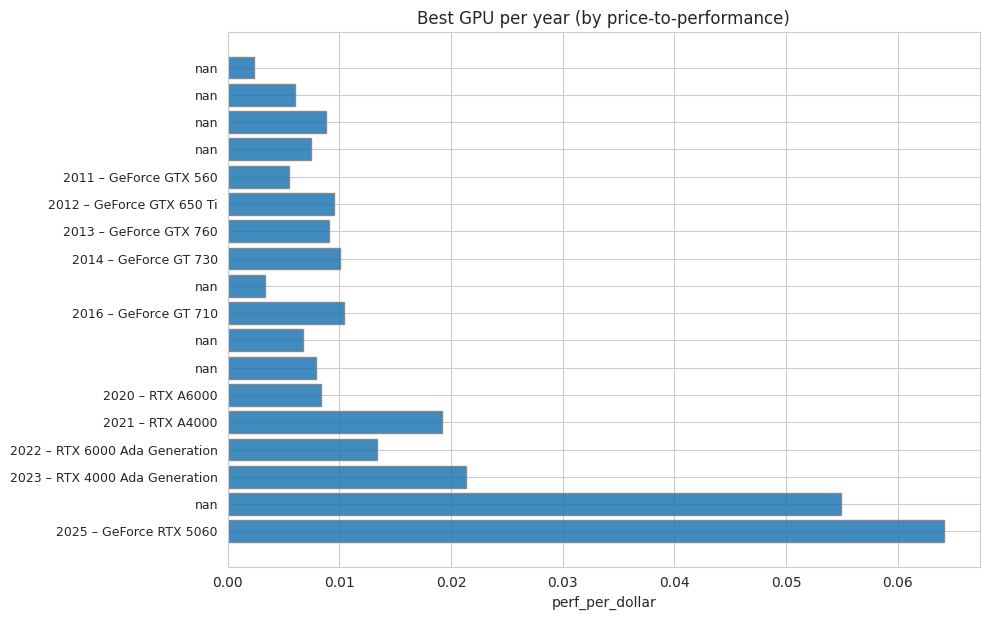

In [52]:
# Horizontal bar chart so model names fit on y-axis without overlap
bp = best_per_year.copy()
bp["launch_year"] = bp["launch_year"].astype(int)
bp["label"] = bp["launch_year"].astype(str) + " – " + bp["Model name"].astype(str)

fig, ax = plt.subplots(figsize=(10, max(6, len(bp) * 0.35)))
y_pos = np.arange(len(bp))
ax.barh(y_pos, bp["perf_per_dollar"], edgecolor="gray", alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels(bp["label"], fontsize=9)
ax.set_xlabel("perf_per_dollar")
ax.set_title("Best GPU per year (by price-to-performance)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Export cleaned table and yearly aggregates

In [53]:
out_cols = ["Model name", "Vendor", "Launch", "launch_year", "price_usd_clean", "perf_value", "perf_per_dollar"]
core[out_cols].to_csv(DATA_PROC / "gpu_clean.csv", index=False)

gpu_yearly = core.groupby("launch_year").agg(
    median_gpu_price=("price_usd_clean", "median"),
    median_perf_per_dollar=("perf_per_dollar", "median"),
    count=("perf_per_dollar", "count"),
).reset_index()
gpu_yearly = gpu_yearly.rename(columns={"launch_year": "year"})
gpu_yearly.to_csv(DATA_PROC / "gpu_yearly.csv", index=False)
print("Saved gpu_clean.csv and gpu_yearly.csv")
gpu_yearly.tail(10)

Saved gpu_clean.csv and gpu_yearly.csv


,year,median_gpu_price,median_perf_per_dollar,count
8,2015.0,2857.0,0.001505,3
9,2016.0,438.0,0.004138,3
10,2017.0,375.0,0.005342,5
11,2018.0,4299.0,0.003720,4
12,2020.0,4649.0,0.008327,1
13,2021.0,724.5,0.017788,4
14,2022.0,3600.0,0.012792,3
15,2023.0,1750.0,0.016967,4
16,2024.0,365.0,0.018490,5
17,2025.0,429.0,0.030516,11
